## Partie 1 : Exploration du dataset
On écrit une fonction `get_image_info` qui extrait, pour chaque image : nom, classe, format, mode, largeur, hauteur, écart-type des pixels, nombre de canaux et taille du fichier.
Les fichiers corrompus sont pris en charge avec un `try/except` : on garde leur ligne avec `corrupted=True` et les autres valeurs vides.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

In [3]:
def get_image_info(path: Path, label: str) -> dict:
    # Dictionnaire qui va contenir toutes les informations de l'image
    info = {
        # Nom du fichier
        "name": path.name,

        # Classe de l'image (ex: glass, plastic, metal...)
        "class": label,

        # Chemin complet de l'image
        "path": str(path),

        # Informations qui seront récupérées après ouverture de l'image
        "format": None,
        "mode": None,
        "width": None,
        "height": None,
        "std": None,
        "channels": None,

        # Taille du fichier en Ko
        "size_kb": round(path.stat().st_size / 1024, 2),

        # On considère l'image comme valide au départ
        "corrupted": False,
    }

    try:
        # Ouvre l'image avec Pillow
        with Image.open(path) as img:

            # Force le chargement complet de l'image
            # Cela permet notamment de détecter les fichiers tronqués ou corrompus
            img.load()

            # Convertit l'image en tableau NumPy
            arr = np.array(img)

            # Récupération des caractéristiques de l'image
            info.update({
                # Format du fichier : JPEG, PNG, WEBP...
                "format": img.format,

                # Mode de l'image : RGB, L, RGBA...
                "mode": img.mode,

                # Largeur de l'image en pixels
                "width": img.width,

                # Hauteur de l'image en pixels
                "height": img.height,

                # Écart-type des valeurs des pixels
                "std": float(arr.std()),

                # Nombre de canaux :
                # 1 si l'image est en niveaux de gris (2 dimensions)
                # sinon on récupère le nombre de canaux dans la 3e dimension
                "channels": 1 if arr.ndim == 2 else arr.shape[2],
            })

    # Si une erreur se produit lors de l'ouverture ou du chargement
    # l'image est considérée comme corrompue
    except Exception:
        info["corrupted"] = True

    # Retourne toutes les informations de l'image
    return info

On définit le chemin du dossier `raw` et la liste des classes, puis on parcourt chaque sous-dossier pour appliquer `get_image_info` à chaque fichier. Le résultat est rassemblé dans un DataFrame `df`.

In [4]:
RAW_DIR = Path("../data/raw")
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

rows = []
for label in CLASSES:
    for path in sorted((RAW_DIR / label).glob("*")):
        if path.is_file():
            rows.append(get_image_info(path, label))

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(1032, 11)


,name,class,path,format,mode,width,height,std,channels,size_kb,corrupted
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,JPEG,RGB,512.0,384.0,40.588529,3.0,16.93,False
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,JPEG,RGB,512.0,384.0,42.571288,3.0,21.17,False
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,JPEG,RGB,512.0,384.0,46.108305,3.0,14.54,False
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,JPEG,RGB,512.0,384.0,72.263996,3.0,13.95,False
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,JPEG,RGB,512.0,384.0,48.388937,3.0,17.59,False


On vérifie la structure du DataFrame : nombre de lignes, types des colonnes et valeurs manquantes. Les valeurs manquantes correspondent aux fichiers corrompus.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       1032 non-null   str    
 1   class      1032 non-null   str    
 2   path       1032 non-null   str    
 3   format     1026 non-null   str    
 4   mode       1026 non-null   str    
 5   width      1026 non-null   float64
 6   height     1026 non-null   float64
 7   std        1026 non-null   float64
 8   channels   1026 non-null   float64
 9   size_kb    1032 non-null   float64
 10  corrupted  1032 non-null   bool   
dtypes: bool(1), float64(5), str(5)
memory usage: 81.8 KB


## Partie 2 : Détecter les images corrompues
On écrit une fonction `is_corrupted(path)` qui renvoie `True` si l'image ne peut pas être ouverte ou décodée entièrement.
On procède en deux temps : `verify()` contrôle la structure du fichier, puis on rouvre l'image et on appelle `load()` pour forcer le décodage complet des pixels (`verify()` seul ne détecte pas tous les fichiers tronqués).

In [6]:
def is_corrupted(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()      # vérifie la structure du fichier
        with Image.open(path) as img:
            img.load()        # force le décodage complet des pixels
        return False
    except Exception:
        return True

On applique la fonction à toutes les images du DataFrame, puis on affiche les images corrompues.

In [7]:
df["is_corrupted"] = df["path"].apply(lambda p: is_corrupted(Path(p)))

print("Nombre d'images corrompues :", df["is_corrupted"].sum())
df[df["is_corrupted"]][["name", "class", "size_kb"]]

Nombre d'images corrompues : 6


,name,class,size_kb
147,cardboard83.jpg,cardboard,20.40
326,glass74.jpg,glass,7.02
446,metal48.jpg,metal,7.09
633,paper213.jpg,paper,7.12
791,plastic13.jpg,plastic,5.13
1004,trash3.jpg,trash,8.98


## Partie 3 : Détecter les images vides
On écrit une fonction `is_empty(path, std_threshold)` qui renvoie `True` si l'image est :
- entièrement noire (tous les pixels valent 0) ;
- entièrement blanche (tous les pixels valent 255) ;
- quasi uniforme : l'écart-type des pixels est inférieur à un seuil, donc très peu de variation.

On convertit d'abord l'image en niveaux de gris (`L`) pour travailler sur un seul canal. Les images corrompues renvoient `False` ici, car elles sont déjà traitées à la Partie 2.

In [8]:
def is_empty(path: Path, std_threshold: float = 5.0) -> bool:
    try:
        with Image.open(path) as img:
            gray = np.array(img.convert("L"))
    except Exception:
        return False  # image corrompue : gérée à la Partie 2

    if gray.max() == 0:        # entièrement noire
        return True
    if gray.min() == 255:      # entièrement blanche
        return True
    return gray.std() < std_threshold  # très peu de variation

On applique la fonction à toutes les images, puis on affiche celles détectées comme vides, triées par écart-type croissant.

In [9]:
df["is_empty"] = df["path"].apply(lambda p: is_empty(Path(p)))

print("Nombre d'images vides ou quasi vides :", df["is_empty"].sum())
df[df["is_empty"]][["name", "class", "std"]].sort_values("std")

Nombre d'images vides ou quasi vides : 4


,name,class,std
167,image-blanche-512x384.jpg,cardboard,1.572536
357,image-blanche-512x384.jpg,metal,1.572536
355,image-noire-512x384.png,glass,110.418239
358,image-noire-512x384.png,metal,110.418239


## Partie 4 : Détecter les différences de résolution
On isole les images lisibles (non corrompues), on convertit largeur et hauteur en entiers (elles étaient en décimaux à cause des valeurs vides), puis on crée deux colonnes : `resolution` (au format `largeurxhauteur`) et `pixels` (largeur × hauteur, pour comparer la taille des images).

In [10]:
df_valid = df[~df["corrupted"]].copy()

df_valid["width"] = df_valid["width"].astype(int)
df_valid["height"] = df_valid["height"].astype(int)
df_valid["resolution"] = df_valid["width"].astype(str) + "x" + df_valid["height"].astype(str)
df_valid["pixels"] = df_valid["width"] * df_valid["height"]

df_valid[["name", "width", "height", "resolution", "pixels"]].head()

,name,width,height,resolution,pixels
0,cardboard1.jpg,512,384,512x384,196608
1,cardboard10.jpg,512,384,512x384,196608
2,cardboard100.jpg,512,384,512x384,196608
3,cardboard101.jpg,512,384,512x384,196608
4,cardboard102.jpg,512,384,512x384,196608


### 4.1 Résolution minimale, maximale, résolutions les plus fréquentes et nombre d'images par résolution
La résolution minimale et maximale sont celles de l'image qui a le moins et le plus de pixels au total.

In [11]:
i_min = df_valid["pixels"].idxmin()
i_max = df_valid["pixels"].idxmax()

print("Résolution minimale :", df_valid.loc[i_min, "resolution"], "->", df_valid.loc[i_min, "name"])
print("Résolution maximale :", df_valid.loc[i_max, "resolution"], "->", df_valid.loc[i_max, "name"])

Résolution minimale : 32x32 -> cardboard22.jpg
Résolution maximale : 512x384 -> cardboard1.jpg


In [12]:
res_counts = df_valid["resolution"].value_counts()
print("Nombre de résolutions différentes :", len(res_counts))
res_counts.head(10)

Nombre de résolutions différentes : 4


resolution
512x384    1013
32x32         5
48x32         4
40x40         4
Name: count, dtype: int64

### 4.2 Images plus petites que 64 × 64
Une image respecte la contrainte si sa largeur **et** sa hauteur sont au moins égales à `MIN_SIZE`. On ajoute une colonne `too_small` au DataFrame principal pour la réutiliser dans l'audit.

In [13]:
MIN_SIZE = 64

df["too_small"] = (df["width"] < MIN_SIZE) | (df["height"] < MIN_SIZE)

print("Nombre d'images trop petites :", df["too_small"].sum())
df[df["too_small"]][["name", "class", "width", "height"]]

Nombre d'images trop petites : 13


,name,class,width,height
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


## Partie 5 : Détecter les différents canaux
Le nombre de canaux indique le type de l'image :
- 1 canal : niveaux de gris (mode `L`)
- 3 canaux : couleur RGB
- 4 canaux : RGB + transparence, RGBA (mode `RGBA`)

On compte le nombre d'images pour chaque valeur de `channels`. La colonne était en décimaux à cause des valeurs vides, on la convertit en entiers.

In [14]:
df_valid["channels"] = df_valid["channels"].astype(int)

channel_counts = df_valid["channels"].value_counts().sort_index()
channel_counts

channels
1       2
3    1006
4      18
Name: count, dtype: int64

On croise avec le mode Pillow (`L`, `RGB`, `RGBA`, `P`...) pour vérifier que les canaux correspondent bien aux modes attendus.

In [15]:
pd.crosstab(df_valid["mode"], df_valid["channels"])

channels,1,3,4
mode,,,
P,2,0,0
RGB,0,1006,0
RGBA,0,0,18


## Partie 6 : Détecter les doublons
On écrit une fonction `image_hash(path)` qui calcule une empreinte MD5 à partir du contenu des pixels : l'image est convertie en RGB, puis on hache ses dimensions et ses octets. Deux images de même contenu ont la même empreinte, même avec des noms de fichier différents. Les images corrompues renvoient `None`.

In [16]:
import hashlib

def image_hash(path: Path):
    # On essaie d'ouvrir et de lire l'image
    try:
        with Image.open(path) as img:

            # On convertit l'image en RGB
            # pour avoir le même format pour toutes les images
            rgb = img.convert("RGB")

            # On crée un hash MD5 vide
            h = hashlib.md5()

            # On ajoute les dimensions de l'image au hash
            # Exemple : (512, 384)
            h.update(str(rgb.size).encode())

            # On ajoute les données des pixels au hash
            h.update(rgb.tobytes())

            # On retourne l'empreinte MD5 sous forme de texte
            return h.hexdigest()

    # Si l'image est corrompue ou impossible à lire
    except Exception:
        # On retourne None
        return None


On calcule l'empreinte de chaque image, puis on marque comme doublon toute image dont l'empreinte est déjà apparue plus haut dans le tableau (`keep="first"` conserve la première occurrence). Les images corrompues (empreinte vide) sont exclues du calcul.

In [17]:
df["hash"] = df["path"].apply(lambda p: image_hash(Path(p)))

df["is_duplicate"] = df["hash"].notna() & df.duplicated(subset="hash", keep="first")

print("Nombre de doublons :", df["is_duplicate"].sum())

Nombre de doublons : 15


On affiche les groupes d'images identiques (toutes les copies, y compris la première), triés par empreinte, pour voir quels fichiers et quelles classes sont concernés.

In [18]:
dup_groups = df[df["hash"].notna() & df.duplicated(subset="hash", keep=False)]
dup_groups.sort_values("hash")[["name", "class", "hash"]]

,name,class,hash
757,paperer35.jpg,paper,084d6885beb9cd78023af968673c277a
686,paper35.jpg,paper,084d6885beb9cd78023af968673c277a
804,plastic140y.jpg,plastic,19b5274a449d2eeecb64f8043b7f1c0a
803,plastic140.jpg,plastic,19b5274a449d2eeecb64f8043b7f1c0a
167,image-blanche-512x384.jpg,cardboard,4506e56263533f8f8c509b66ab10dd82
357,image-blanche-512x384.jpg,metal,4506e56263533f8f8c509b66ab10dd82
732,paper77ty.jpg,paper,53bdf6ad66903e0fc02b35b3cad77a43
731,paper77.jpg,paper,53bdf6ad66903e0fc02b35b3cad77a43
910,plastic36rt.jpg,plastic,6945d4f24986bcb2a77cdfca092496b1
909,plastic36.jpg,plastic,6945d4f24986bcb2a77cdfca092496b1


## Partie 7 : Détecter les images mal classées

Le contrôle a été fait **visuellement et à la main** : chaque dossier de `data/raw` a été parcouru dans l'explorateur de fichiers en affichage miniatures, et les images qui ne correspondent pas à leur classe ont été relevées.

### Résultat du contrôle visuel

| N° | Image | Classe du dossier | Classe réelle | Ce que montre l'image |
|----|-------|-------------------|---------------|-----------------------|
| 1 | cardboard86d | cardboard | plastic | une bouteille |
| 2 | cardboard161 | cardboard | glass | un objet en verre |
| 3 | glass12er | glass | paper | du papier |
| 4 | metal150 | metal | cardboard | un carton |
| 5 | paper30 | paper | cardboard | un carton |
| 6 | paper200 | paper | cardboard | un carton |
| 7 | paper201 | paper | metal | un objet en métal |
| 8 | plastic109 | plastic | cardboard | un carton |

### Conclusion de la Partie 7

- **8 images mal classées** ont été détectées.
- La classe `cardboard` est la classe réelle de 4 d'entre elles, mais elle contient aussi 2 intruses (une bouteille en plastique et un objet en verre).
- Ces erreurs sont dangereuses pour l'entraînement : le modèle apprendrait des associations fausses (par exemple « bouteille = carton »).
- Le dossier `raw` reste **inchangé** (lecture seule). Ces 8 images seront traitées lors de la construction du dossier `cleaned`.
- Les images `image-blanche-512x384.jpg` et `image-noire-512x384.png`, présentes dans plusieurs classes, sont comptées à part avec les images vides (Partie 3) et les doublons (Partie 6).

## Partie 8 : Analyser le déséquilibre des classes
On compte le nombre d'images par classe dans le dataset brut, puis on calcule leur pourcentage. Une classe est dite **minoritaire** quand elle a nettement moins d'images que les autres : le modèle a alors moins d'exemples pour l'apprendre et a tendance à la négliger.

In [19]:
class_counts = df["class"].value_counts()

class_stats = pd.DataFrame({
    "nb_images": class_counts,
    "pourcentage": (class_counts / len(df) * 100).round(1),
})
class_stats

,nb_images,pourcentage
class,,
paper,252,24.4
plastic,224,21.7
glass,188,18.2
cardboard,169,16.4
metal,149,14.4
trash,50,4.8


**Observations :**
- Le dataset est **déséquilibré**. Avec 6 classes, une répartition parfaitement équilibrée donnerait environ 16,7 % par classe.
- La classe majoritaire est `paper` (252 images) et la classe minoritaire est `trash` (50 images) : le rapport est d'environ **5 pour 1**.
- `trash` est très en dessous des autres classes (4,8 % contre au moins 14,4 % pour les autres).
- Ce comptage porte sur le dataset **brut** : il inclut encore les images corrompues, vides, dupliquées et mal classées. Il sera recalculé sur le dataset nettoyé.

**Risque :** un modèle entraîné sur ces données verra très peu d'exemples de `trash` et aura tendance à l'ignorer, même s'il obtient une bonne précision globale.

**Conséquence :** la classe `trash` recevra la data augmentation, après le découpage train/validation/test.

## Partie 9 : Redimensionnement
Avant de redimensionner, on sélectionne les images à conserver dans `cleaned`. On écarte :
- les images corrompues (Partie 2) ;
- les images vides ou quasi vides (Partie 3) ;
- les images trop petites, moins de 64 × 64 (Partie 4) ;
- les doublons, en gardant la première occurrence (Partie 6) ;
- les images mal classées (Partie 7).

Le dossier `raw` n'est jamais modifié : on ne fait que marquer les images dans le DataFrame.

In [20]:
misclassified = [
    # (nom sans extension, classe du dossier, classe réelle)
    ("cardboard86d", "cardboard", "plastic"),
    ("cardboard161", "cardboard", "glass"),
    ("glass12er", "glass", "paper"),
    ("metal150", "metal", "cardboard"),
    ("paper30", "paper", "cardboard"),
    ("paper200", "paper", "cardboard"),
    ("paper201", "paper", "metal"),
    ("plastic109", "plastic", "cardboard"),
]

df["stem"] = df["name"].str.rsplit(".", n=1).str[0]

df_mis = pd.DataFrame(misclassified, columns=["stem", "class", "true_class"])
df_mis = df_mis.merge(df[["stem", "class", "name"]], on=["stem", "class"], how="left")

print("Images mal classées :", len(df_mis))
df_mis[["name", "class", "true_class"]]

Images mal classées : 8


,name,class,true_class
0,cardboard86d.jpg,cardboard,plastic
1,cardboard161.jpg,cardboard,glass
2,glass12er.jpg,glass,paper
3,metal150.jpg,metal,cardboard
4,paper30.jpg,paper,cardboard
5,paper200.jpg,paper,cardboard
6,paper201.jpg,paper,metal
7,plastic109.jpg,plastic,cardboard


In [21]:
mis_keys = set(zip(df_mis["name"].dropna(), df_mis["class"]))
df["is_misclassified"] = [(n, c) in mis_keys for n, c in zip(df["name"], df["class"])]

df["to_remove"] = (
    df["corrupted"]
    | df["is_empty"]
    | df["too_small"]
    | df["is_duplicate"]
    | df["is_misclassified"]
)

print("Images totales      :", len(df))
print("Images à retirer    :", df["to_remove"].sum())
print("Images conservées   :", (~df["to_remove"]).sum())

df_keep = df[~df["to_remove"]].copy()

Images totales      : 1032
Images à retirer    : 44
Images conservées   : 988


In [22]:
TARGET_SIZE = 224

def resize_with_padding(img: Image.Image, size: int = TARGET_SIZE, fill=(0, 0, 0)) -> Image.Image:
    img = img.convert("RGB")
    w, h = img.size

    scale = size / max(w, h)
    new_w = max(1, round(w * scale))
    new_h = max(1, round(h * scale))
    resized = img.resize((new_w, new_h), Image.LANCZOS)

    canvas = Image.new("RGB", (size, size), fill)
    canvas.paste(resized, ((size - new_w) // 2, (size - new_h) // 2))
    return canvas

On teste la fonction sur une seule image avant de traiter tout le dataset : la sortie doit faire 224 × 224 en RGB, avec l'image centrée et des bandes noires en haut et en bas.

Avant : (512, 384) RGB
Après : (224, 224) RGB


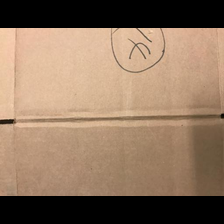

In [23]:
test_path = df_keep.iloc[0]["path"]

with Image.open(test_path) as img:
    print("Avant :", img.size, img.mode)
    result = resize_with_padding(img)
    print("Après :", result.size, result.mode)

result

On crée le dossier `cleaned` avec un sous-dossier par classe, puis on redimensionne chaque image conservée (`df_keep`) en 224 × 224 avec padding. Les images sont enregistrées en PNG, un format sans perte, pour ne pas dégrader la qualité une deuxième fois. Le dossier `raw` n'est jamais modifié.

In [24]:
CLEANED_DIR = Path("../data/cleaned")

for label in CLASSES:
    (CLEANED_DIR / label).mkdir(parents=True, exist_ok=True)

for _, row in df_keep.iterrows():
    with Image.open(row["path"]) as img:
        out = resize_with_padding(img)
    out.save(CLEANED_DIR / row["class"] / (Path(row["name"]).stem + ".png"))

print("Redimensionnement terminé.")

Redimensionnement terminé.


On vérifie le résultat : le nombre d'images par classe dans `cleaned` doit correspondre à `df_keep`, et toutes les images doivent faire 224 × 224 en RGB.

In [25]:
counts = {c: len(list((CLEANED_DIR / c).glob("*.png"))) for c in CLASSES}
print("Images par classe dans cleaned :", counts)
print("Total :", sum(counts.values()), "| attendu :", len(df_keep))

bad = []
for p in CLEANED_DIR.rglob("*.png"):
    with Image.open(p) as im:
        if im.size != (224, 224) or im.mode != "RGB":
            bad.append(p.name)
print("Images non conformes :", len(bad))

Images par classe dans cleaned : {'cardboard': 162, 'glass': 180, 'metal': 138, 'paper': 242, 'plastic': 217, 'trash': 49}
Total : 988 | attendu : 988
Images non conformes : 0


## Partie 10 : Uniformisation des canaux
Le dataset brut contient trois types d'images : RGB (3 canaux), RGBA (4 canaux, avec transparence) et P (palette, 1 canal). Un modèle attend le même nombre de canaux pour toutes les images : on convertit tout en **RGB**.

Cette conversion est faite dans `resize_with_padding` avec `img.convert("RGB")` :
- RGBA vers RGB : le canal alpha (transparence) est supprimé ;
- P vers RGB : chaque numéro de la palette est remplacé par sa vraie couleur.

On montre d'abord l'effet de la conversion sur une image RGBA et une image P du dataset brut.

In [26]:
for mode in ["RGBA", "P"]:
    row = df_keep[df_keep["mode"] == mode]
    if row.empty:
        print(mode, ": aucune image conservée avec ce mode")
        continue
    path = row.iloc[0]["path"]
    with Image.open(path) as img:
        converted = img.convert("RGB")
        print(row.iloc[0]["name"], "| avant :", img.mode, np.array(img).shape, "| après :", converted.mode, np.array(converted).shape)

cardboard13v.png | avant : RGBA (384, 512, 4) | après : RGB (384, 512, 3)
image-violet-512x384.gif | avant : P (384, 512) | après : RGB (384, 512, 3)


On vérifie que **toutes** les images du dossier `cleaned` sont bien en RGB, avec 3 canaux.

In [27]:
from collections import Counter

modes = Counter()
for p in CLEANED_DIR.rglob("*.png"):
    with Image.open(p) as im:
        modes[im.mode] += 1

print("Modes dans cleaned :", dict(modes))

Modes dans cleaned : {'RGB': 988}


## Partie 11 : Mise à l'échelle des pixels
Les pixels sont des entiers de 0 à 255 (`uint8`). On les **normalise** entre 0 et 1 :
1. on convertit le tableau en décimaux (`float32`) ;
2. on divise par 255.

Un pixel de valeur 0 reste 0, un pixel de 255 devient 1, et un pixel de 128 devient environ 0,5. Cette échelle commune aide l'entraînement d'un modèle (calculs plus stables, convergence plus rapide).

On n'enregistre pas les images normalisées sur le disque : en `float32`, elles pèseraient environ 4 fois plus qu'en `uint8` (près de 600 Mo pour 988 images). On garde les PNG dans `cleaned` et on normalise **au moment du chargement**.

In [28]:
def normalize_image(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        arr = np.array(img.convert("RGB"), dtype=np.float32)
    return arr / 255.0

On teste la fonction sur une image de `cleaned` : on compare le type et les valeurs minimale et maximale avant et après normalisation.

In [29]:
p = next(CLEANED_DIR.rglob("*.png"))

with Image.open(p) as im:
    avant = np.array(im)

apres = normalize_image(p)

print("Image :", p.name)
print("Avant :", avant.dtype, "| min =", avant.min(), "| max =", avant.max())
print("Après :", apres.dtype, "| min =", round(float(apres.min()), 3), "| max =", round(float(apres.max()), 3))

Image : cardboard1.png
Avant : uint8 | min = 0 | max = 253
Après : float32 | min = 0.0 | max = 0.992


On vérifie sur **toutes** les images de `cleaned` que les valeurs sont bien comprises entre 0 et 1.


In [30]:
g_min, g_max = 1.0, 0.0

for p in CLEANED_DIR.rglob("*.png"):
    a = normalize_image(p)
    g_min = min(g_min, float(a.min()))
    g_max = max(g_max, float(a.max()))

print("Minimum global :", g_min)
print("Maximum global :", g_max)

Minimum global : 0.0
Maximum global : 1.0


## Partie 12 : Découpage Train / Validation / Test
On liste les images du dossier `cleaned` dans un DataFrame `df_clean` (chemin et classe), puis on découpe en deux étapes avec `train_test_split` :
1. 80 % pour le train, 20 % pour le reste ;
2. le reste est coupé en deux : 10 % validation et 10 % test.

L'option `stratify` conserve la proportion de chaque classe dans les trois groupes, et `random_state=42` rend le découpage reproductible.

In [31]:
from sklearn.model_selection import train_test_split

files = sorted(CLEANED_DIR.rglob("*.png"))
df_clean = pd.DataFrame({
    "path": [str(p) for p in files],
    "class": [p.parent.name for p in files],
})

train_df, temp_df = train_test_split(
    df_clean, test_size=0.20, stratify=df_clean["class"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class"], random_state=42
)

print("Total :", len(df_clean))
print("Train :", len(train_df), "| Validation :", len(val_df), "| Test :", len(test_df))

Total : 988
Train : 790 | Validation : 99 | Test : 99


## Partie 13 : Data augmentation
### 13.1 Augmentation de la classe minoritaire avec Keras
La data augmentation se fait **uniquement sur le train**, jamais sur la validation ni le test : ces deux groupes doivent rester des images réelles, pour évaluer honnêtement le modèle.

On repère d'abord la classe minoritaire du train et on calcule combien d'images il faut créer pour la rapprocher des autres classes.

In [32]:
train_counts = train_df["class"].value_counts()
print(train_counts)

minority = train_counts.idxmin()
target = int(train_counts.sort_values().iloc[1])   # taille de la 2e plus petite classe
n_to_create = target - train_counts[minority]

print("\nClasse minoritaire :", minority)
print("Objectif           :", target, "images")
print("À créer            :", n_to_create, "images")

class
paper        193
plastic      174
glass        144
cardboard    130
metal        110
trash         39
Name: count, dtype: int64

Classe minoritaire : trash
Objectif           : 110 images
À créer            : 71 images


On définit la chaîne de transformations avec Keras. Chaque transformation est **aléatoire** : à chaque appel, elle produit une variante différente de l'image.

| Transformation | Réglage | Effet |
|----------------|---------|-------|
| Retournement horizontal | `RandomFlip("horizontal")` | miroir gauche-droite |
| Rotation légère | `RandomRotation(0.04)` | environ ±14° |
| Zoom | `RandomZoom(0.15)` | agrandit ou réduit de 15 % au maximum |
| Translation | `RandomTranslation(0.1, 0.1)` | décale de 10 % au maximum |
| Luminosité | `RandomBrightness(0.2)` | plus clair ou plus sombre |
| Contraste | `RandomContrast(0.2)` | plus ou moins contrasté |
| Légère variation de couleur | `tf.image.random_hue` et `random_saturation` | teinte et saturation modifiées légèrement |

Les zones libérées par la rotation, le zoom et la translation sont remplies en noir (`fill_mode="constant"`), comme le padding de la Partie 9.

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04, fill_mode="constant"),
    layers.RandomZoom(0.15, fill_mode="constant"),
    layers.RandomTranslation(0.1, 0.1, fill_mode="constant"),
    layers.RandomBrightness(0.2, value_range=(0, 255)),
    layers.RandomContrast(0.2),
])

def augment_image(arr: np.ndarray) -> np.ndarray:
    """arr : image (224, 224, 3) en uint8 -> renvoie une variante augmentée en uint8."""
    x = tf.convert_to_tensor(arr[None, ...], dtype=tf.float32)   # ajoute la dimension du lot
    x = augmenter(x, training=True)[0] / 255.0                   # training=True active le hasard
    x = tf.image.random_hue(x, 0.03)
    x = tf.image.random_saturation(x, 0.8, 1.2)
    x = tf.clip_by_value(x * 255.0, 0, 255)
    return x.numpy().astype("uint8")

On teste la chaîne sur une image `trash` du train : on affiche l'original et 7 variantes générées au hasard.

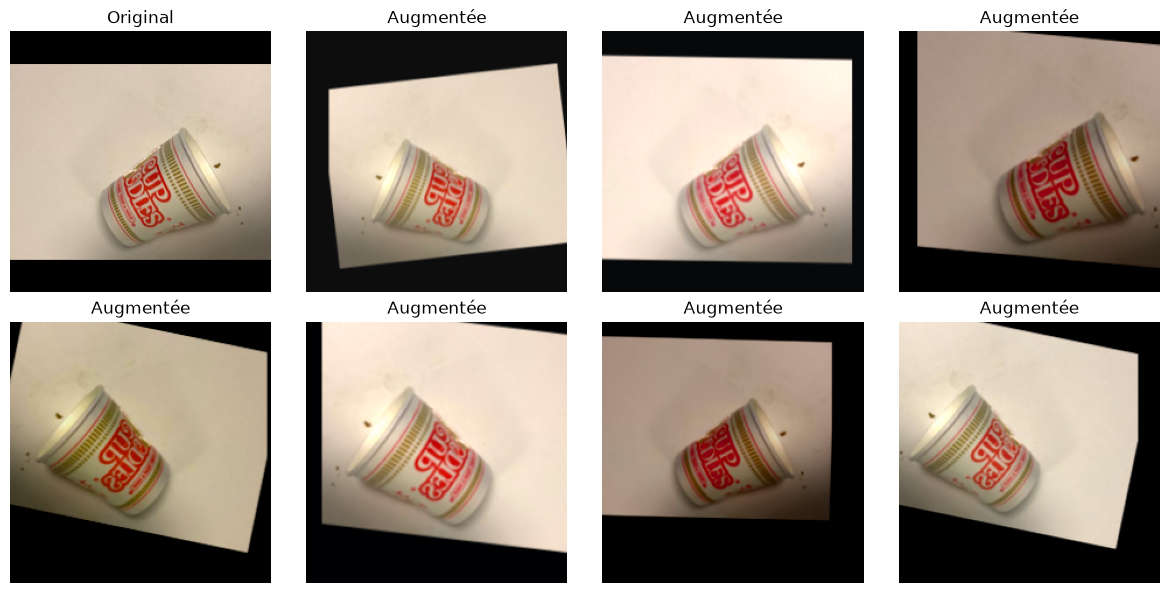

In [36]:
trash_paths = train_df[train_df["class"] == "trash"]["path"].tolist()

with Image.open(trash_paths[0]) as im:
    original = np.array(im)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(original)
axes[0, 0].set_title("Original")

for ax in axes.flat[1:]:
    ax.imshow(augment_image(original))
    ax.set_title("Augmentée")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

On génère `n_to_create` (71) images augmentées de la classe `trash`. On parcourt les images `trash` du train en boucle (39 images, donc certaines servent deux fois) et on applique à chacune une variante aléatoire. Les images créées sont enregistrées dans `data/augmented/trash`, **séparé de `cleaned`**, pour ne pas mélanger images réelles et images synthétiques. `set_random_seed(42)` rend le résultat reproductible.

In [37]:
AUG_DIR = Path("../data/augmented/trash")
AUG_DIR.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(42)

sources = train_df[train_df["class"] == minority]["path"].tolist()

for i in range(n_to_create):
    src = Path(sources[i % len(sources)])          # revient au début quand on a fait tout le tour
    with Image.open(src) as im:
        arr = np.array(im.convert("RGB"))
    out = Image.fromarray(augment_image(arr))
    out.save(AUG_DIR / f"{src.stem}_aug{i:03d}.png")

print("Images créées :", len(list(AUG_DIR.glob("*.png"))))

Images créées : 71


On compare la répartition du train avant et après augmentation. Seule la classe `trash` change.

In [38]:
nb_aug = len(list(AUG_DIR.glob("*.png")))

apres = train_counts.copy()
apres[minority] += nb_aug

comparaison = pd.DataFrame({"train avant": train_counts, "train après": apres})
comparaison

,train avant,train après
class,,
paper,193,193
plastic,174,174
glass,144,144
cardboard,130,130
metal,110,110
trash,39,110


### Conclusion de 13.1
La classe minoritaire `trash` (39 images dans le train) a été portée à **110 images** par data augmentation Keras (retournement horizontal, rotation légère, zoom, translation, luminosité, contraste, légère variation de teinte et de saturation). 71 images ont été créées à partir des seules images `trash` du train, et enregistrées dans `data/augmented/trash`, séparées de `cleaned`. Les ensembles de validation et de test n'ont pas été touchés.

### 13.2 Pourquoi éviter la data augmentation avant le découpage du dataset ?

Parce qu'on créerait une **fuite de données** (*data leakage*).

Une image augmentée est une variante d'une image d'origine : elle lui ressemble presque exactement (même objet, même fond, légèrement décalé ou éclairci). Si on augmente **avant** le découpage, les variantes d'une même image sont ensuite réparties au hasard entre train, validation et test. On peut alors avoir :
- l'image d'origine dans le **train** ;
- sa variante (retournée, légèrement tournée) dans le **test**.

Conséquences :
- Le modèle est évalué sur des images qu'il a déjà pratiquement vues à l'entraînement. Le score obtenu est **artificiellement élevé** et ne reflète pas ses vraies performances sur de nouvelles photos.
- Le test et la validation ne jouent plus leur rôle : mesurer la capacité à **généraliser** à des images inconnues.
- On ne peut plus détecter le surapprentissage (*overfitting*), puisque validation et test contiennent des quasi-copies du train.

**Bonne pratique :**
1. nettoyer le dataset (retirer les doublons, les images corrompues, etc.) ;
2. découper en train, validation et test ;
3. augmenter **uniquement le train**.

La validation et le test restent ainsi composés d'images réelles, jamais vues par le modèle, ce qui donne une évaluation honnête. C'est le même principe que pour les doublons de la Partie 6 : une même image ne doit jamais se retrouver des deux côtés du découpage.